In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import random
print("All packages imported successfully.")

All packages imported successfully.


Random Quantum Circuit Generated
Seed             : 84776
Number of Qubits : 9
Circuit Depth    : 14
Total Gates      : 91


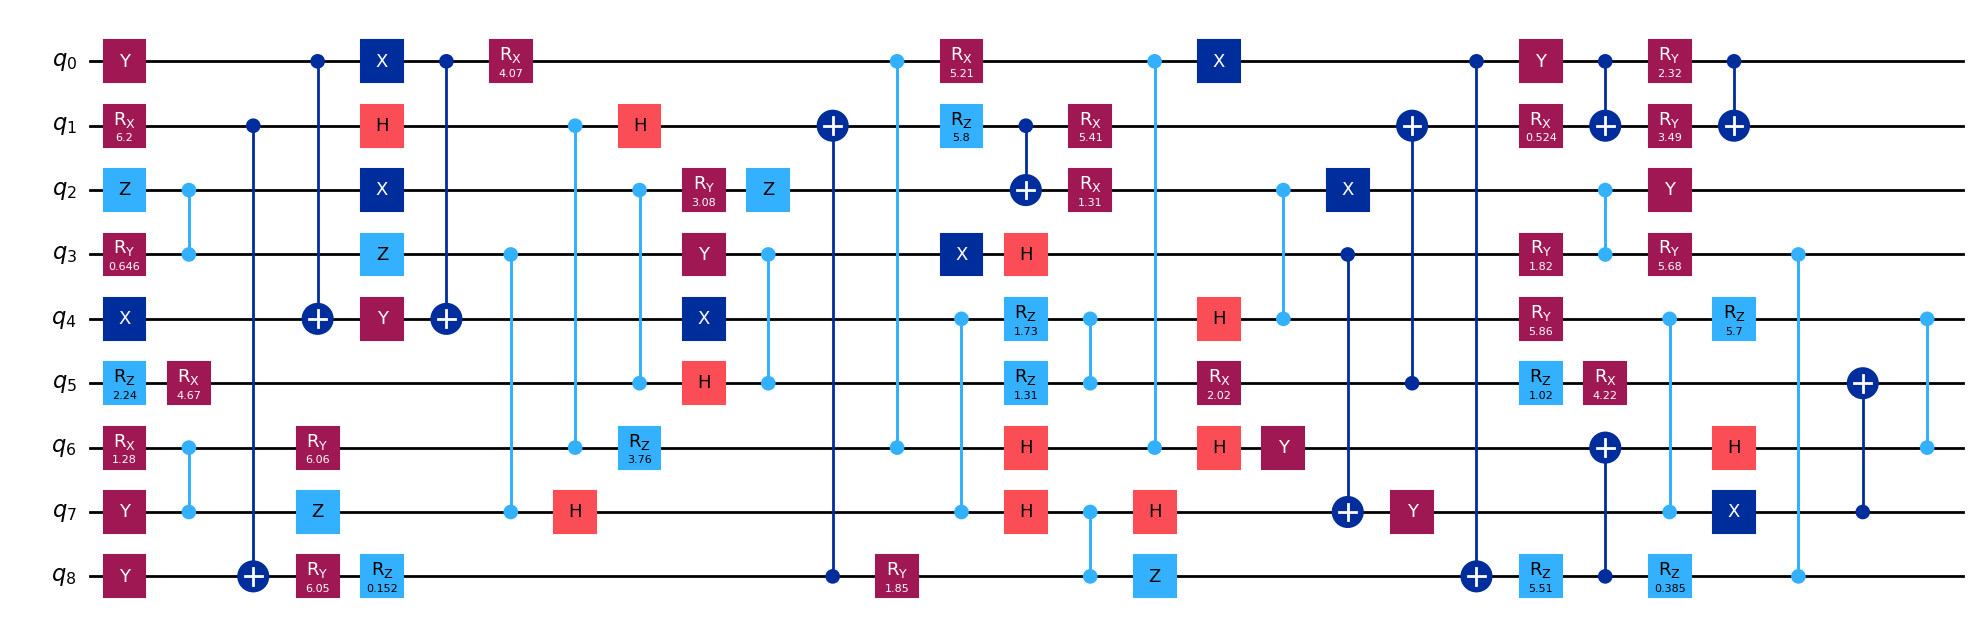

In [2]:

def generate_random_circuit():
    seed = random.randint(0, 99999)
    random.seed(seed)
    np.random.seed(seed)
    
    num_qubits = random.randint(4, 12)
    depth = random.randint(5, 10)
    qc = QuantumCircuit(num_qubits)
    
    single_gates = ['h', 'x', 'y', 'z', 'rx', 'ry', 'rz']
    two_gates = ['cx', 'cz']
    
    for _ in range(depth):
        for q in range(num_qubits):
            gate = random.choice(single_gates)
            if gate in ['rx', 'ry', 'rz']:
                theta = np.random.uniform(0, 2 * np.pi)
                getattr(qc, gate)(theta, q)
            else:
                getattr(qc, gate)(q)
        
        qubits = random.sample(range(num_qubits), num_qubits)
        for i in range(0, num_qubits - 1, 2):
            gate = random.choice(two_gates)
            if gate == 'cx':
                qc.cx(qubits[i], qubits[i + 1])
            else:
                qc.cz(qubits[i], qubits[i + 1])
    
    print("=" * 50)
    print("Random Quantum Circuit Generated")
    print(f"Seed             : {seed}")
    print(f"Number of Qubits : {num_qubits}")
    print(f"Circuit Depth    : {qc.depth()}")
    print(f"Total Gates      : {len(qc.data)}")
    print("=" * 50)
    
    return qc

qc = generate_random_circuit()

qc.draw("mpl", fold=40)

In [3]:
def circuit_to_graph(circuit):
    G = nx.Graph()
    for q in range(circuit.num_qubits):
        G.add_node(q, label=f"q{q}")
    for instruction in circuit.data:
        if len(instruction.qubits) == 2:
            q0 = circuit.qubits.index(instruction.qubits[0])
            q1 = circuit.qubits.index(instruction.qubits[1])
            gate_name = instruction.operation.name
            G.add_edge(q0, q1, gate=gate_name)
    return G

G = circuit_to_graph(qc)
print("Qubit Interaction Graph")
print(f"  Nodes (qubits) : {G.number_of_nodes()}")
print(f"  Edges (2q gates): {G.number_of_edges()}")
print("\nEdge list:")
for u, v, data in G.edges(data=True):
    print(f"  q{u} -- q{v}  [{data['gate'].upper()}]")

Qubit Interaction Graph
  Nodes (qubits) : 9
  Edges (2q gates): 21

Edge list:
  q0 -- q4  [CX]
  q0 -- q6  [CZ]
  q0 -- q8  [CX]
  q0 -- q1  [CX]
  q1 -- q8  [CX]
  q1 -- q6  [CZ]
  q1 -- q2  [CX]
  q1 -- q5  [CX]
  q2 -- q3  [CZ]
  q2 -- q5  [CZ]
  q2 -- q4  [CZ]
  q3 -- q7  [CX]
  q3 -- q5  [CZ]
  q3 -- q8  [CZ]
  q4 -- q7  [CZ]
  q4 -- q5  [CZ]
  q4 -- q6  [CZ]
  q5 -- q7  [CX]
  q6 -- q7  [CZ]
  q6 -- q8  [CX]
  q7 -- q8  [CZ]


In [4]:
def spectral_partition(G, num_qubits):
    """
    Spectral Partitioning using the Fiedler vector.
    Steps:
      1. Build the Laplacian matrix L = Degree - Adjacency
      2. Compute its eigenvectors
      3. Take the Fiedler vector (2nd smallest eigenvalue)
      4. Sort qubits by Fiedler value, split at the median
    """
    node_order = sorted(G.nodes())
    start_time = time.time()

    L = nx.laplacian_matrix(G, nodelist=node_order).toarray().astype(float)
    eigenvalues, eigenvectors = np.linalg.eigh(L)
    fiedler_vector = eigenvectors[:, 1]

    half = num_qubits // 2
    sorted_nodes = sorted(node_order, key=lambda q: fiedler_vector[node_order.index(q)])
    partA = set(sorted_nodes[:half])
    partB = set(sorted_nodes[half:])

    runtime = time.time() - start_time

    cut_edges = [
        (u, v, data["gate"])
        for u, v, data in G.edges(data=True)
        if (u in partA) != (v in partA)
    ]
    return (partA, partB), cut_edges, len(cut_edges), runtime


print("Running Spectral Partitioning...")
best_partition, best_cut_edges, minimum_cut_count, sp_runtime = \
    spectral_partition(G, qc.num_qubits)

partA, partB = best_partition

print("\n" + "=" * 50)
print("  SPECTRAL PARTITION RESULTS")
print("=" * 50)
print(f"  Runtime                : {sp_runtime:.4f} seconds")
print(f"  Minimum Cut Count      : {minimum_cut_count}")
print()
print(f"  Group A (qubits) : {sorted(partA)}")
print(f"  Group B (qubits) : {sorted(partB)}")
print()
print("  Cut Gates (cross-partition):")
for u, v, gate in best_cut_edges:
    print(f"    {gate.upper():5s}  q{u}  <-->  q{v}")
print("=" * 50)

Running Spectral Partitioning...

  SPECTRAL PARTITION RESULTS
  Runtime                : 3.0912 seconds
  Minimum Cut Count      : 7

  Group A (qubits) : [0, 1, 2, 3, 6, 7]
  Group B (qubits) : [4, 5, 8, 9, 10, 11]

  Cut Gates (cross-partition):
    CRZ    q2  <-->  q8
    CZ     q2  <-->  q5
    CX     q3  <-->  q4
    CRZ    q3  <-->  q9
    CX     q5  <-->  q6
    CZ     q6  <-->  q9
    CX     q7  <-->  q8


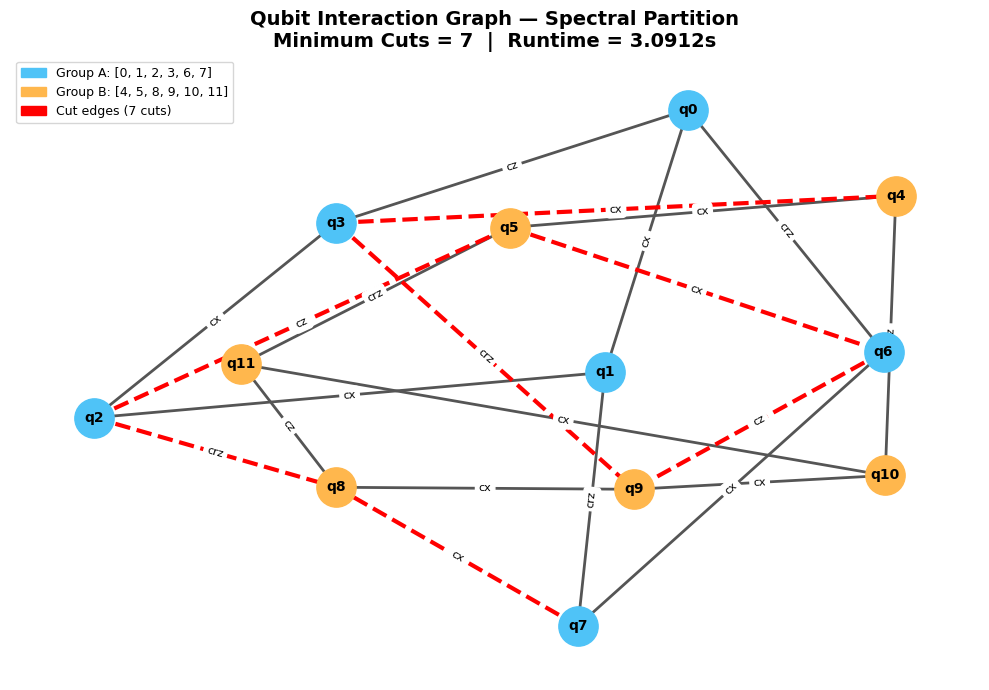

In [5]:
def draw_interaction_graph(G, partA, partB, cut_edges_list, title="Qubit Interaction Graph"):
    fig, ax = plt.subplots(figsize=(10, 7))
    pos = nx.spring_layout(G, seed=42, k=1.5)
    cut_edge_set   = {(u, v) for u, v, _ in cut_edges_list} | \
                     {(v, u) for u, v, _ in cut_edges_list}
    internal_edges = [(u, v) for u, v in G.edges() if (u, v) not in cut_edge_set]
    cut_edges_draw = [(u, v) for u, v in G.edges() if (u, v) in cut_edge_set]
    nx.draw_networkx_nodes(G, pos, nodelist=list(partA),
                           node_color="#4fc3f7", node_size=800, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=list(partB),
                           node_color="#ffb74d", node_size=800, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=internal_edges,
                           width=2.0, edge_color="#555555", ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=cut_edges_draw,
                           width=3.0, edge_color="red", style="dashed", ax=ax)
    nx.draw_networkx_labels(G, pos,
                            labels={n: f"q{n}" for n in G.nodes()},
                            font_size=10, font_weight="bold", ax=ax)
    edge_labels = nx.get_edge_attributes(G, "gate")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=8, ax=ax)
    legend_handles = [
        mpatches.Patch(color="#4fc3f7", label=f"Group A: {sorted(partA)}"),
        mpatches.Patch(color="#ffb74d", label=f"Group B: {sorted(partB)}"),
        mpatches.Patch(color="red",     label=f"Cut edges ({len(cut_edges_list)} cuts)"),
    ]
    ax.legend(handles=legend_handles, loc="upper left", fontsize=9)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

draw_interaction_graph(
    G, partA, partB, best_cut_edges,
    title=f"Qubit Interaction Graph — Spectral Partition\n"
          f"Minimum Cuts = {minimum_cut_count}  |  Runtime = {sp_runtime:.4f}s"
)

Subcircuit A — qubits [0, 1, 2, 3, 6, 7]
  Gates: 13, Depth: 5


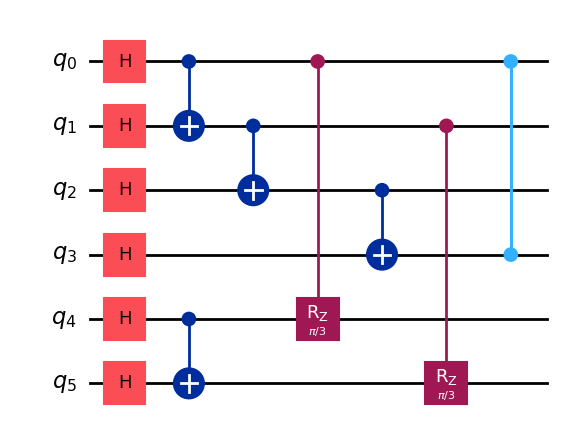

In [6]:
def extract_subcircuit(circuit, qubit_group, cut_edges):
    """
    Extracts the subcircuit for a given qubit group.
    - Keeps all single-qubit gates on qubits in the group.
    - Keeps 2-qubit gates where BOTH qubits are in the group (internal gates).
    - Removes cross-partition (cut) gates.
    Returns a QuantumCircuit using only the qubits in the group,
    re-indexed from 0.
    """
    sorted_group = sorted(qubit_group)
    qubit_map    = {old: new for new, old in enumerate(sorted_group)}
    n_sub        = len(sorted_group)
    sub_qc       = QuantumCircuit(n_sub)
    cut_pairs = {(u, v) for u, v, _ in cut_edges} | \
                {(v, u) for u, v, _ in cut_edges}
    for instruction in circuit.data:
        qubit_indices = [
            circuit.qubits.index(q) for q in instruction.qubits
        ]
        if len(qubit_indices) == 1:
            q = qubit_indices[0]
            if q in qubit_group:
                sub_qc.append(instruction.operation, [qubit_map[q]])
        elif len(qubit_indices) == 2:
            q0, q1 = qubit_indices
            if q0 in qubit_group and q1 in qubit_group:
                if (q0, q1) not in cut_pairs:
                    sub_qc.append(
                        instruction.operation,
                        [qubit_map[q0], qubit_map[q1]]
                    )
    return sub_qc, sorted_group

sub_A, qubits_A = extract_subcircuit(qc, partA, best_cut_edges)
sub_B, qubits_B = extract_subcircuit(qc, partB, best_cut_edges)
print(f"Subcircuit A — qubits {qubits_A}")
print(f"  Gates: {len(sub_A.data)}, Depth: {sub_A.depth()}")
sub_A.draw("mpl")

Subcircuit B — qubits [4, 5, 8, 9, 10, 11]
  Gates: 13, Depth: 6


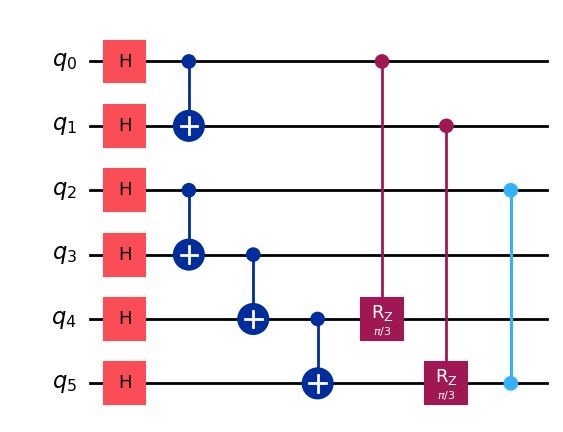

In [7]:
print(f"Subcircuit B — qubits {qubits_B}")
print(f"  Gates: {len(sub_B.data)}, Depth: {sub_B.depth()}")
sub_B.draw("mpl")

--- Reconstructed Circuit (cut gates removed) ---
Original depth    : 14
Reconstructed depth: 6
Gates removed     : 7 (the 7 cut gates)


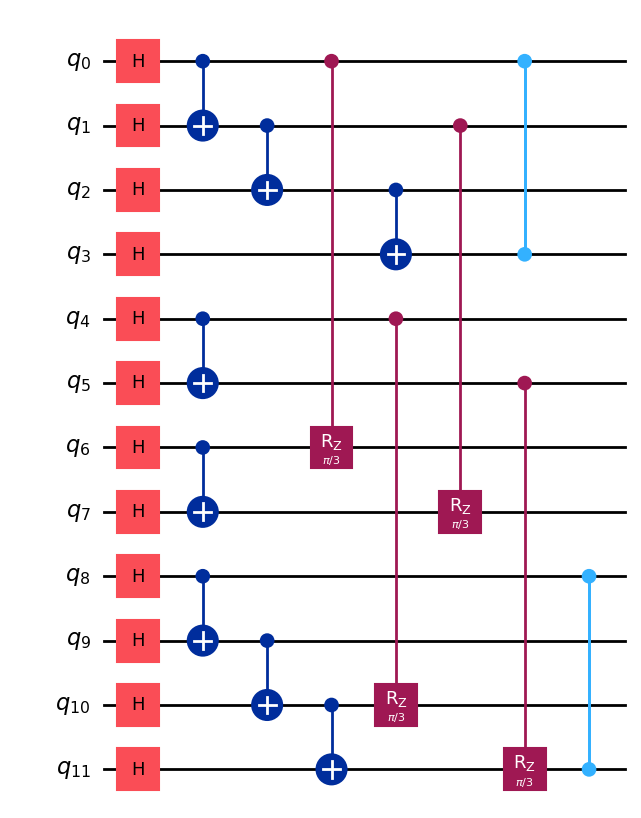

In [8]:
def reconstruct_circuit(circuit, cut_edges):
    """
    Approximate reconstruction: rebuilds the original circuit
    with all cross-partition gates removed.
    This represents running the two subcircuits independently
    without any cross-partition entanglement.
    """
    cut_pairs = {(u, v) for u, v, _ in cut_edges} | \
                {(v, u) for u, v, _ in cut_edges}
    reconstructed = QuantumCircuit(circuit.num_qubits)
    for instruction in circuit.data:
        qubit_indices = [
            circuit.qubits.index(q) for q in instruction.qubits
        ]
        if len(qubit_indices) == 2:
            q0, q1 = qubit_indices
            if (q0, q1) in cut_pairs:
                continue
        reconstructed.append(instruction.operation, qubit_indices)
    return reconstructed

reconstructed_qc = reconstruct_circuit(qc, best_cut_edges)
print("--- Reconstructed Circuit (cut gates removed) ---")
print(f"Original depth    : {qc.depth()}")
print(f"Reconstructed depth: {reconstructed_qc.depth()}")
print(f"Gates removed     : {len(qc.data) - len(reconstructed_qc.data)} (the {minimum_cut_count} cut gates)")
reconstructed_qc.draw("mpl", fold=40)

In [9]:
print("Computing statevectors (this may take a moment for 12 qubits)...")
original_sv      = Statevector.from_instruction(qc)
reconstructed_sv = Statevector.from_instruction(reconstructed_qc)
sp_fidelity = state_fidelity(original_sv, reconstructed_sv)
print()
print("=" * 50)
print("  FIDELITY RESULT")
print("=" * 50)
print(f"  Fidelity = {sp_fidelity:.6f}")
print()
if sp_fidelity > 0.99:
    print("  ✓ Very high fidelity — cuts had minimal impact.")
elif sp_fidelity > 0.90:
    print("  ~ Good fidelity — some entanglement lost at cuts.")
else:
    print("  ✗ Low fidelity — significant entanglement lost at cuts.")
print("=" * 50)
print()
print("Note: Fidelity < 1.0 reflects entanglement lost by cutting")
print("cross-partition gates. True reconstruction via Pauli channel")
print("decomposition would restore fidelity = 1.0 at the cost of")
print("additional classical post-processing overhead.")

Computing statevectors (this may take a moment for 12 qubits)...

  FIDELITY RESULT
  Fidelity = 0.058313

  ✗ Low fidelity — significant entanglement lost at cuts.

Note: Fidelity < 1.0 reflects entanglement lost by cutting
cross-partition gates. True reconstruction via Pauli channel
decomposition would restore fidelity = 1.0 at the cost of
additional classical post-processing overhead.


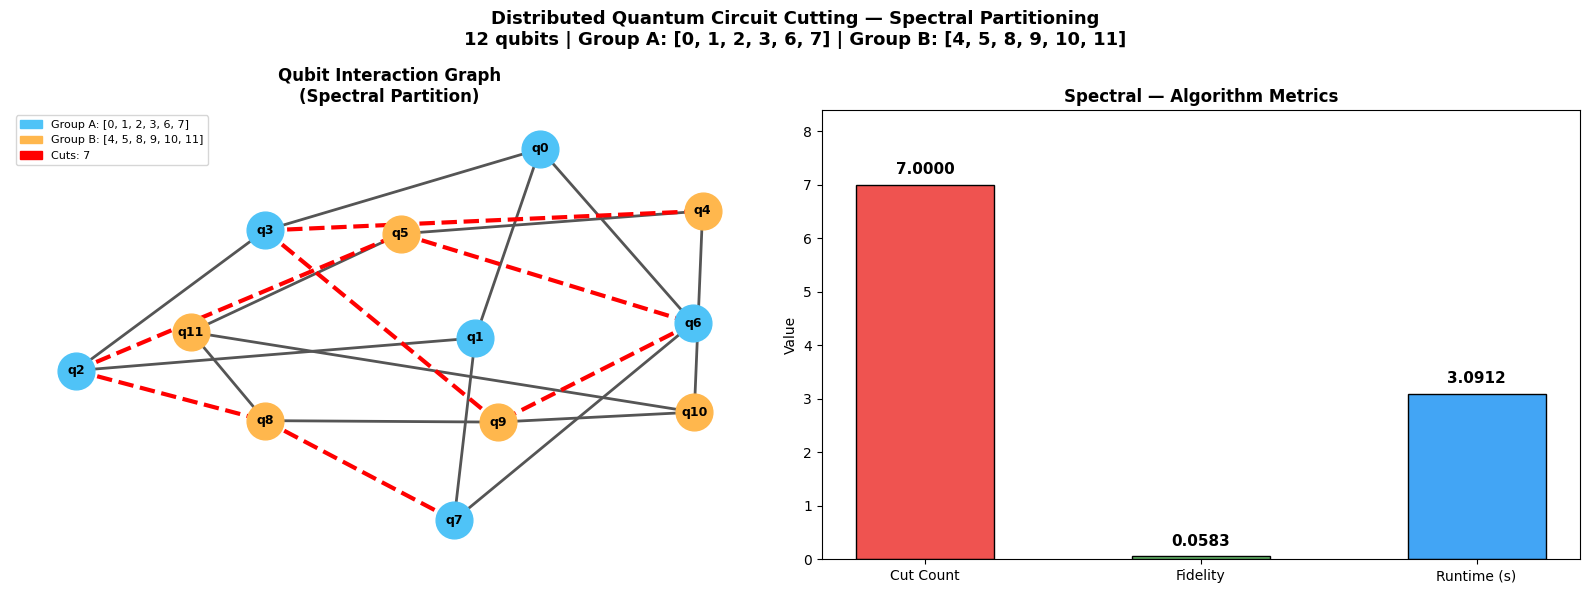

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Qubit Interaction Graph ---
ax = axes[0]
pos = nx.spring_layout(G, seed=42, k=1.5)
cut_pair_set   = {(u, v) for u, v, _ in best_cut_edges} | \
                 {(v, u) for u, v, _ in best_cut_edges}
internal_edges = [(u, v) for u, v in G.edges() if (u, v) not in cut_pair_set]
cut_edges_draw = [(u, v) for u, v in G.edges() if (u, v) in cut_pair_set]
nx.draw_networkx_nodes(G, pos, nodelist=list(partA),
                       node_color="#4fc3f7", node_size=700, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=list(partB),
                       node_color="#ffb74d", node_size=700, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=internal_edges,
                       width=2, edge_color="#555", ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=cut_edges_draw,
                       width=3, edge_color="red", style="dashed", ax=ax)
nx.draw_networkx_labels(G, pos,
                        labels={n: f"q{n}" for n in G.nodes()},
                        font_size=9, font_weight="bold", ax=ax)
legend_handles = [
    mpatches.Patch(color="#4fc3f7", label=f"Group A: {sorted(partA)}"),
    mpatches.Patch(color="#ffb74d", label=f"Group B: {sorted(partB)}"),
    mpatches.Patch(color="red",     label=f"Cuts: {minimum_cut_count}"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8)
ax.set_title("Qubit Interaction Graph\n(Spectral Partition)", fontweight="bold")
ax.axis("off")

# --- Right: Metrics Bar Chart ---
ax2 = axes[1]
metrics = ["Cut Count", "Fidelity", "Runtime (s)"]
values  = [minimum_cut_count, sp_fidelity, sp_runtime]
colors  = ["#ef5350", "#66bb6a", "#42a5f5"]
bars = ax2.bar(metrics, values, color=colors, width=0.5, edgecolor="black")
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(values) * 0.02,
             f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.set_title("Spectral — Algorithm Metrics", fontweight="bold")
ax2.set_ylabel("Value")
ax2.set_ylim(0, max(values) * 1.2)
plt.suptitle(
    f"Distributed Quantum Circuit Cutting — Spectral Partitioning\n"
    f"12 qubits | Group A: {sorted(partA)} | Group B: {sorted(partB)}",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()